## **Inference Notebook for Clustering and Classification using Credit Card Spending Data**

#### By: John Adrian T. Ada

---
### **Abstract** 

---

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import math

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, 
                            silhouette_samples, 
                            calinski_harabasz_score, 
                            davies_bouldin_score)
import umap
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.sklearn

mlflow.sklearn.autolog()
#mlflow server --port 8080

np.random.seed(42)

### **Methods**


---
### **0. Dataset Information**

Dataset and Source: Credit Card Dataset for Clustering (Uploaded by Arjun Bhasin on Kaggle)

https://www.kaggle.com/datasets/arjunbhasin2013/ccdata 


The dataset used summarizes the usage behavior of 8950 active credit card holders over a six-month period with 18 behavioral variables. The following is the Data Dictionary for Credit Card dataset:

| Column Name | Description |
|---|---|
| CUST_ID | Identification of Credit Card holder (Categorical) |
| BALANCE | Balance amount left in their account to make purchases |
| BALANCE_FREQUENCY | How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated) |
| PURCHASES | Amount of purchases made from account |
| ONEOFF_PURCHASES | Maximum purchase amount done in one-go |
| INSTALLMENTS_PURCHASES | Amount of purchase done in installment |
| CASH_ADVANCE | Cash in advance given by the user |
| PURCHASES_FREQUENCY | How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased) |
| ONEOFFPURCHASESFREQUENCY | How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased) |
| PURCHASESINSTALLMENTSFREQUENCY | How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done) |
| CASHADVANCEFREQUENCY | How frequently the cash in advance being paid |
| CASHADVANCETRX | Number of Transactions made with "Cash in Advanced" |
| PURCHASES_TRX | Number of purchase transactions made |
| CREDIT_LIMIT | Limit of Credit Card for user |
| PAYMENTS | Amount of Payment done by user |
| MINIMUM_PAYMENTS | Minimum amount of payments made by user |
| PRCFULLPAYMENT | Percent of full payment paid by user |
| TENURE | Tenure of credit card service for user |

In this project, it was used for consumer segmentation using unsupervised Machine Learning such as Clustering to determine different types of consumers before using Supervised Machine Learning to predict the labels determined from clustering. 

---
### **1. Data Loading, Exploratory Data Analysis and Pre-processing**


In [2]:
df = pd.read_csv(r'../cc-dataset/CC GENERAL.csv')

print(df.columns)
df.head()

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


Some notes:
- No Negative Values for all columns, as expected
- High Standard Deviation, and thus high Variance, for most of the columns with a high range
- There are a missing values, seen in the count column. 
- Large disparity between the mean and median (50%) for the columns with a high range and high variance, suggesting that there are outliers. 

In [4]:
int_cols = list(df.select_dtypes(include=['int64']).columns)
for col in int_cols:
    print(col)
    print(df[col].unique())

CASH_ADVANCE_TRX
[  0   4   1   3   6  13   5  16  10   2  11   7  12  37  27  23  21  14
  40   8   9  26  15  18  28  24  20  17  22  31 123  52  51  62  19  25
  30  29  53  45  43  42 107  38  56  39  32  33  50  34  63  36 110  47
  48  71  35  93  80  44  61  46  49  69  41]
PURCHASES_TRX
[  2   0  12   1   8  64   5   3   6  26  11   9  92  17  13  45  14  41
  27  20  87  18   4  42  61  33   7  50  22  23  60  46  75  31  10  34
  81  25  85 217  19  52 216  97  24  77 130  90  44  39  15  30  36 123
 151  21 101  49  98  28  84  93  72  38  99  62  48  16  32  51  74  29
  59  76  47 126 229  40 103 121 157 114  53  83  43  54 222  66 141  37
  79  70  80 194 117 100 111  67 219  55 152 104 182  88  82  71  78  35
 122 105 108  69 175 135  91  65  68 119  63 140 113 358  58 248 129  56
  89  57 139 176 136 195  73 109 208 115 110 147 273 102 185 171 168 232
  95  86 148 112 128 254 198 298 154 116 142 131 347 204 200  94 118 344
 162 308 199 309  96 274 224 143 133 127 186]
T

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
null_df = pd.DataFrame({'Missing Values': df.isnull().sum(), 'Percentage': round(df.isnull().sum() / df.shape[0] * 100, 2)})

null_df.sort_values('Missing Values', ascending=False)

,Missing Values,Percentage
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01
BALANCE,0,0.00
CUST_ID,0,0.00
BALANCE_FREQUENCY,0,0.00
PURCHASES,0,0.00
CASH_ADVANCE,0,0.00
PURCHASES_FREQUENCY,0,0.00
ONEOFF_PURCHASES,0,0.00
INSTALLMENTS_PURCHASES,0,0.00


count     8637.000000
mean       864.206542
std       2372.446607
min          0.019163
25%        169.123707
50%        312.343947
75%        825.485459
max      76406.207520
Name: MINIMUM_PAYMENTS, dtype: float64


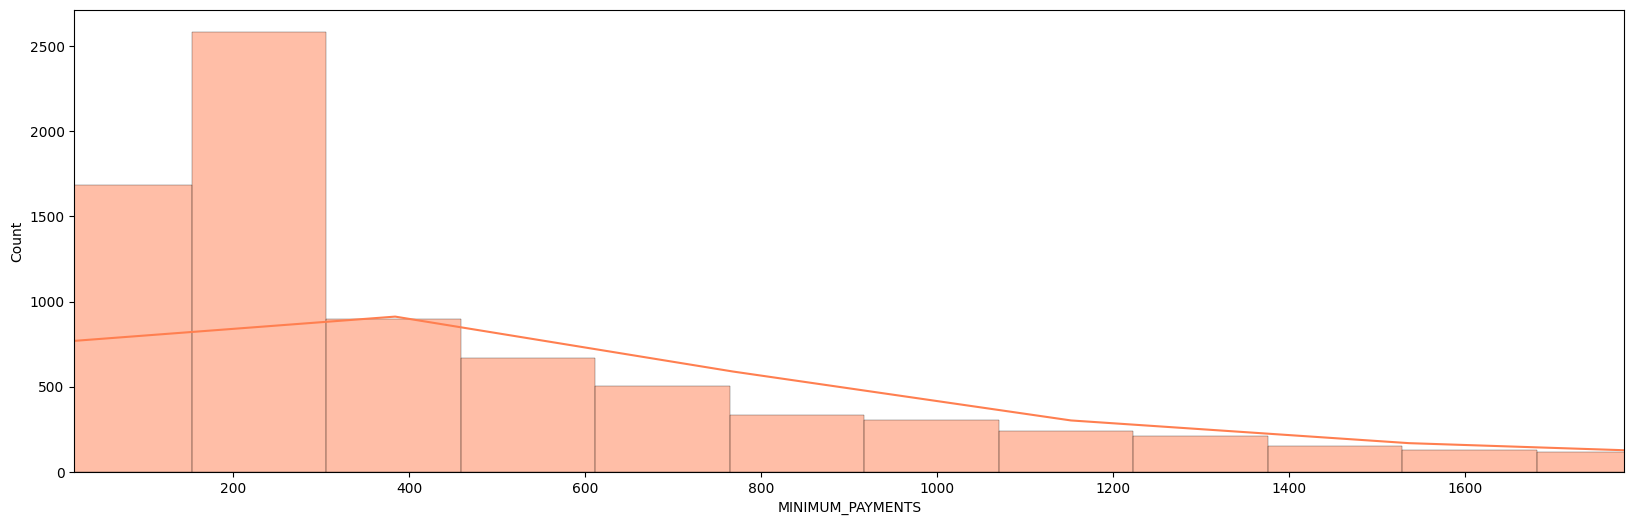

In [7]:
#graph minimum payments
plt.figure(figsize=(20, 6))
p90 = np.percentile(df['MINIMUM_PAYMENTS'], 25)
sns.histplot(df['MINIMUM_PAYMENTS'], kde=True, bins=500, color='coral')
plt.xlim(df['MINIMUM_PAYMENTS'].quantile(0.01), df['MINIMUM_PAYMENTS'].quantile(0.9))

print(df['MINIMUM_PAYMENTS'].describe())

Most of the null values come from the Minimum Payments column. According to the Data Dictionary, it is the Mininum Payments made by a user. By definition, it always has to be less than or equal to the Payments column. From the succeeding cells, Minimum Payments and Credit Limit, the two columns with null values, are continuous and right-skewed. This means that the Median, not the Mean, would be preferred for simple imputing if imputation is done later on. The histplot above shows the Minimum Payments zoomed in on the 90th percentile. Three-quarters of observations have a Minimum_Payments value of 825.50 or under. 

In [8]:
df[df.isnull().any(axis=1)].head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,C10056,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
56,C10058,3625.218146,1.000000,313.27,313.27,0.0,668.468743,0.250000,0.250000,0.000000,0.416667,5,4,4000.0,0.000000,NaN,0.0,12
63,C10065,7.152356,0.090909,840.00,840.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1600.0,0.000000,NaN,0.0,12
93,C10098,1307.717841,1.000000,405.60,405.60,0.0,0.000000,0.166667,0.166667,0.000000,0.000000,0,2,2400.0,0.000000,NaN,0.0,12
94,C10099,2329.485768,1.000000,213.34,213.34,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,3,2400.0,0.000000,NaN,0.0,12
97,C10102,3505.671311,1.000000,0.00,0.00,0.0,1713.984305,0.000000,0.000000,0.000000,0.500000,6,0,4000.0,0.000000,NaN,0.0,12


Since CUST_ID is the unique identifier for the dataset, duplicate records can be checked using this column

In [9]:
print(f"Number of duplicate records: {df['CUST_ID'].duplicated().sum()}")

Number of duplicate records: 0


##### **Distribution**

In [10]:
def plot_all_features_grid(dataframe, max_cols=9):
    """
    Calculates a grid and plots all features in a single large figure.
    Works for any number of dimensions by dynamically calculating grid shape.
    
    Parameters:
    - dataframe: The pandas DataFrame containing features to plot.
    - max_cols: The maximum number of columns for the plot grid.
    """
    print("Generating dynamic grid plot...")
    num_features = len(dataframe.columns)
    
    # Guard clause in case an empty dataframe is passed
    if num_features == 0:
        print("No features to plot.")
        return

    # Don't create more grid columns than actual features
    grid_cols = min(num_features, max_cols)
    grid_rows = math.ceil(num_features / grid_cols)
    
    # Dynamically scale the figure size (approx 3x2.5 inches per subplot)
    fig_width = grid_cols * 3
    fig_height = grid_rows * 2.5
    
    fig, axes = plt.subplots(nrows=grid_rows, ncols=grid_cols, figsize=(fig_width, fig_height))
    
    # Flatten axes array for easy iteration (handles 1x1 case safely)
    if num_features == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, col in enumerate(dataframe.columns):
        # Plot on the specific subplot axis
        sns.histplot(dataframe[col], kde=True, bins=20, ax=axes[i], color='coral')
        
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("") # Remove x-labels to save space
        axes[i].set_ylabel("") # Remove y-labels to save space
        axes[i].tick_params(axis='both', which='major', labelsize=8)

    # Clean up: hide any extra empty subplots if the grid isn't perfectly filled
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    # Adjust layout to prevent title/tick overlap
    plt.tight_layout()
    plt.show()

Generating dynamic grid plot...


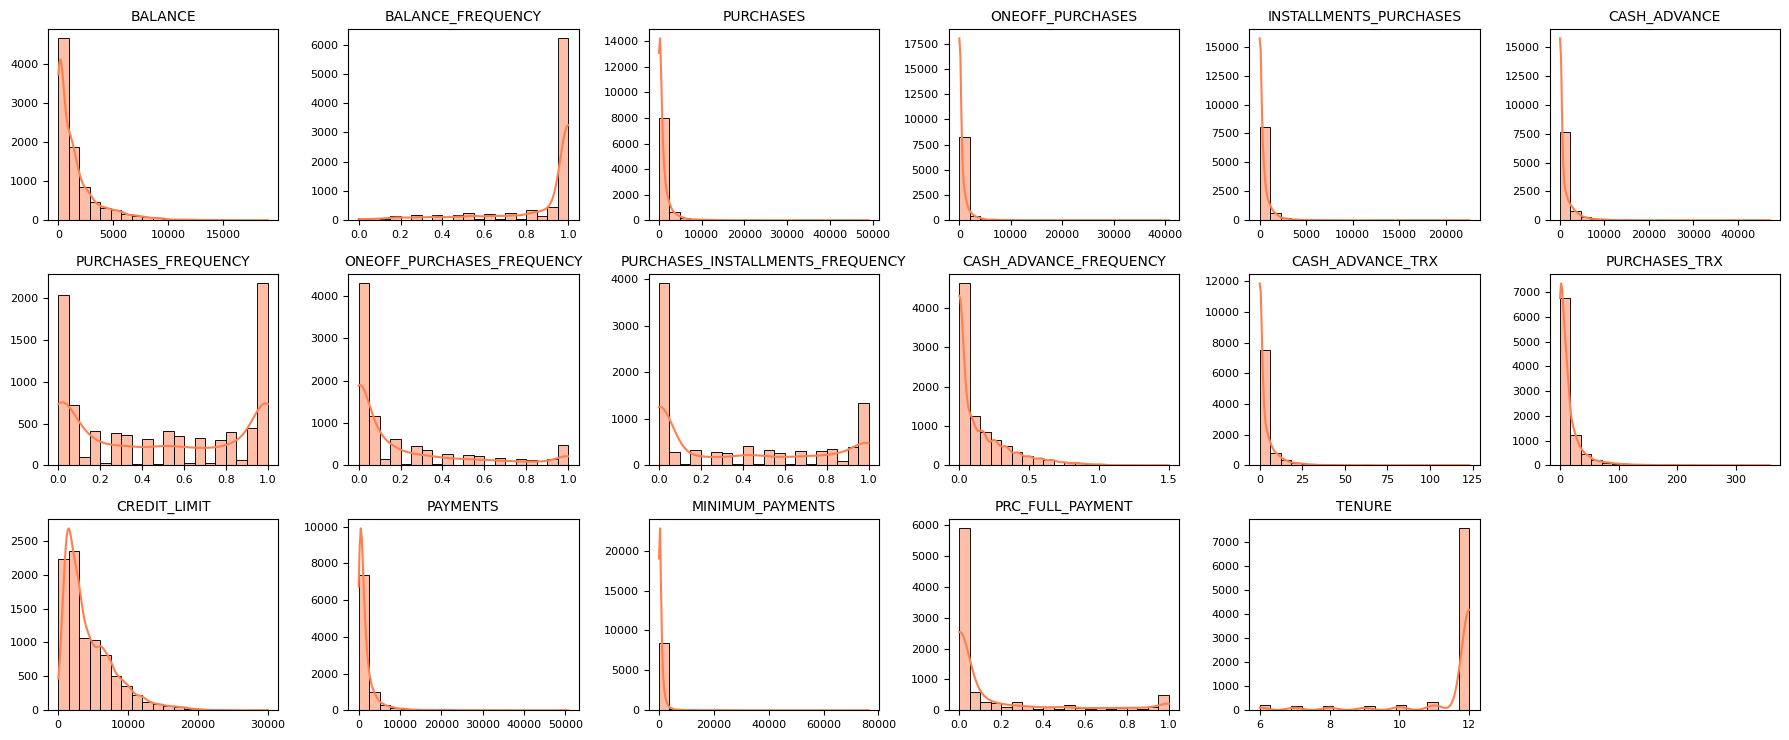

In [11]:
plot_all_features_grid(df.drop('CUST_ID', axis=1), 6)

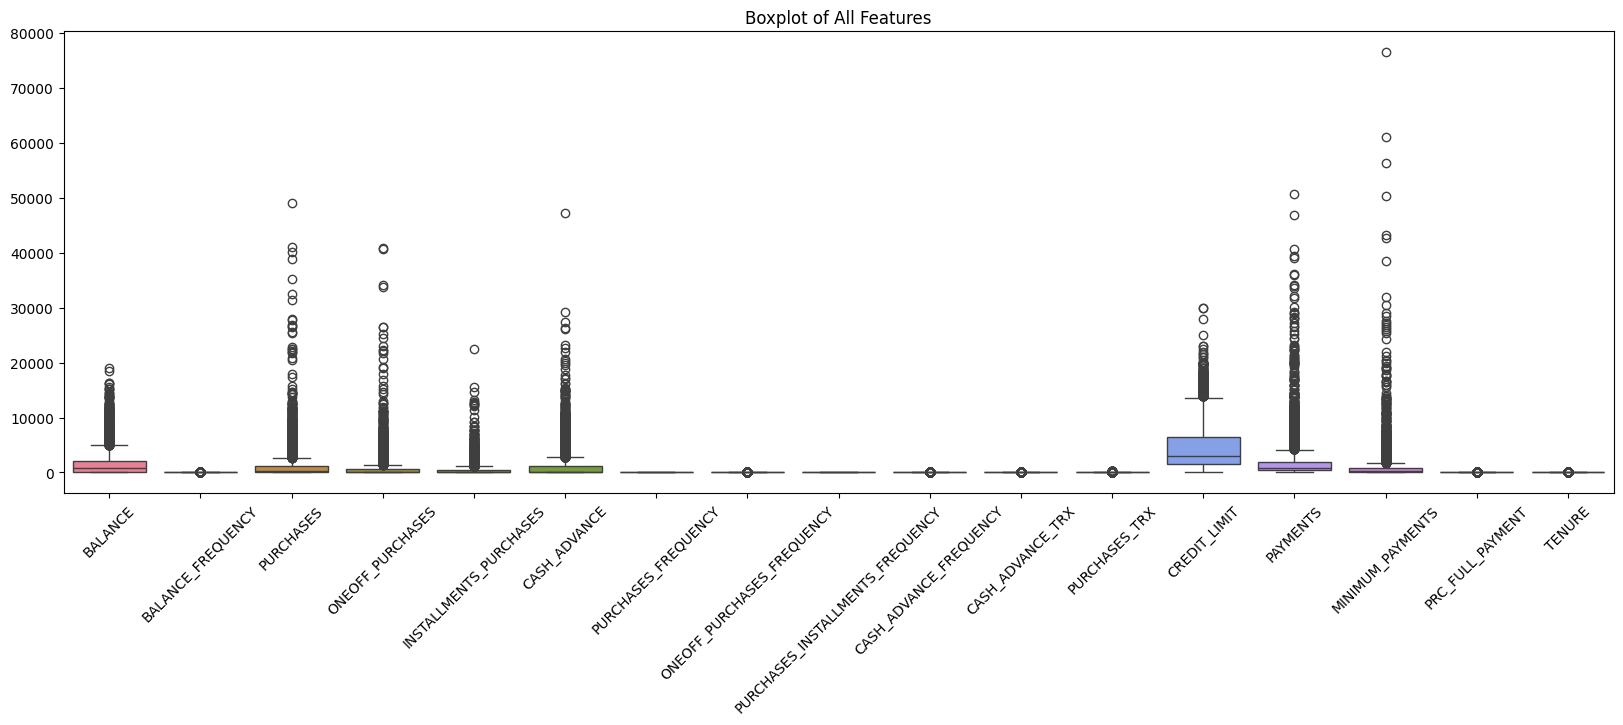

In [12]:
numerical_cols = df.select_dtypes(include=["float64", "int64"])
plt.figure(figsize=(20, 6))
sns.boxplot(numerical_cols)
plt.xticks(rotation=45)  
plt.title("Boxplot of All Features")
plt.show()

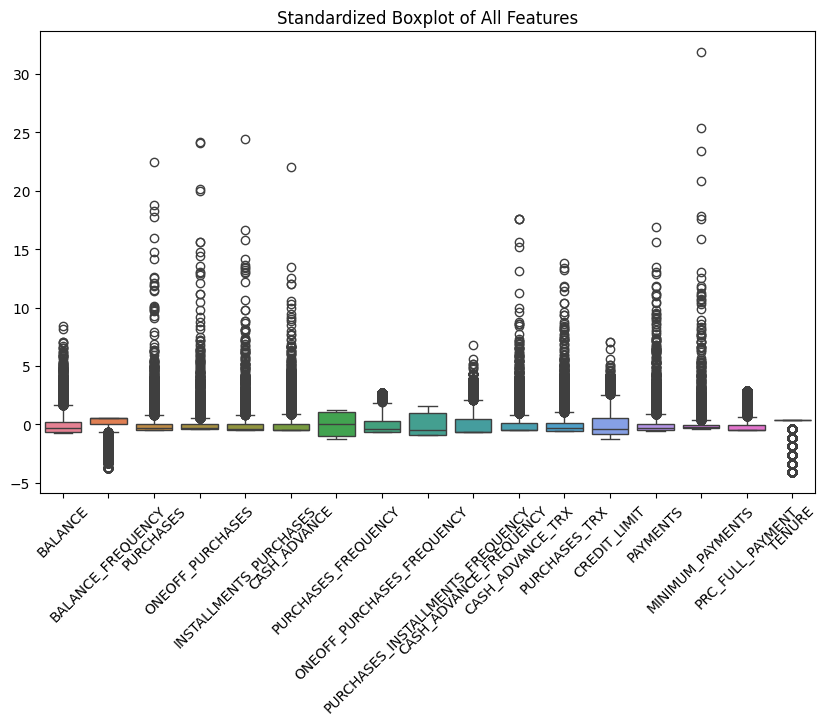

In [13]:
#standardized
numerical_cols = df.select_dtypes(include=["float64", "int64"])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_cols)
scaled_df = pd.DataFrame(scaled_data, columns=numerical_cols.columns)

plt.figure(figsize=(10, 6))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=45)  
plt.title("Standardized Boxplot of All Features")
plt.show()

Most of the features are right-skewed, particularly features relating to money or wealth such as Purchases, Balance, Credit Limit, and Payments. Thus, it is expected that there are significantly less high spenders due to the low frequency (y-axis) of the aforementioned features that exhibit the higher values (x-axis) of their range. 

##### **Correlation Heatmap**

<Axes: >

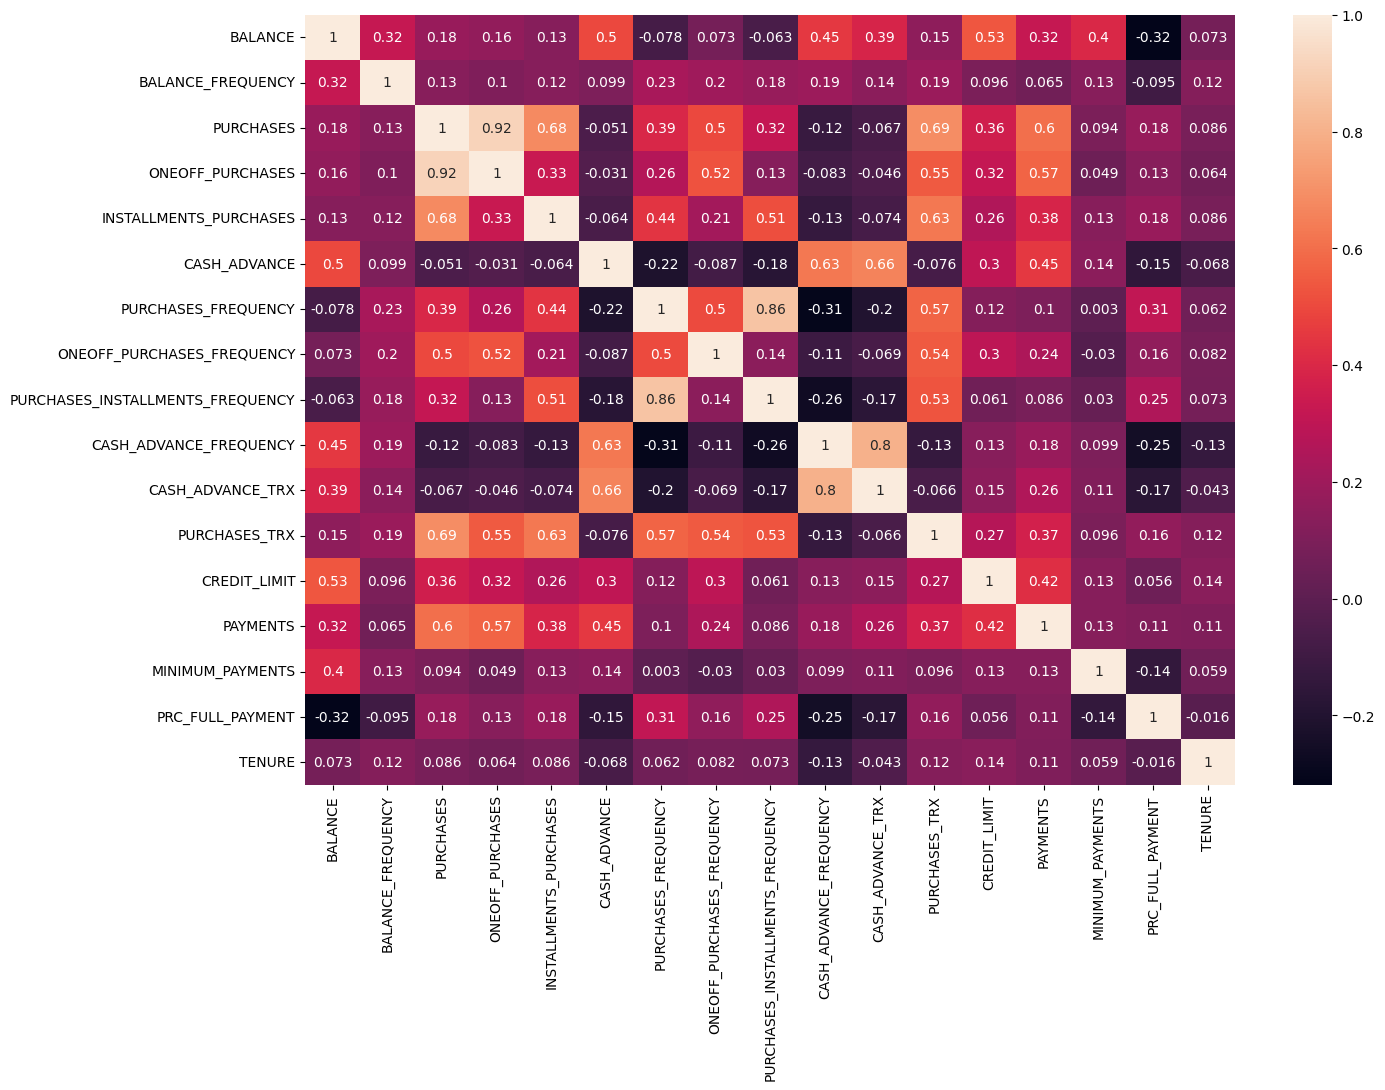

In [14]:
#heatmap correlation
plt.figure(figsize=(15, 10))
sns.heatmap(numerical_cols.corr(), annot=True)

In [15]:
#print max correlation coefficient that are less than 1
masked_corr = numerical_cols.corr().replace(1.0, np.nan)
print(masked_corr.max().sort_values(ascending=False))

PURCHASES                           0.916845
ONEOFF_PURCHASES                    0.916845
PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
PURCHASES_FREQUENCY                 0.862934
CASH_ADVANCE_TRX                    0.799561
CASH_ADVANCE_FREQUENCY              0.799561
PURCHASES_TRX                       0.689561
INSTALLMENTS_PURCHASES              0.679896
CASH_ADVANCE                        0.656498
PAYMENTS                            0.603264
ONEOFF_PURCHASES_FREQUENCY          0.544869
BALANCE                             0.531283
CREDIT_LIMIT                        0.531283
MINIMUM_PAYMENTS                    0.398684
BALANCE_FREQUENCY                   0.322412
PRC_FULL_PAYMENT                    0.305802
TENURE                              0.139167
dtype: float64


<Axes: >

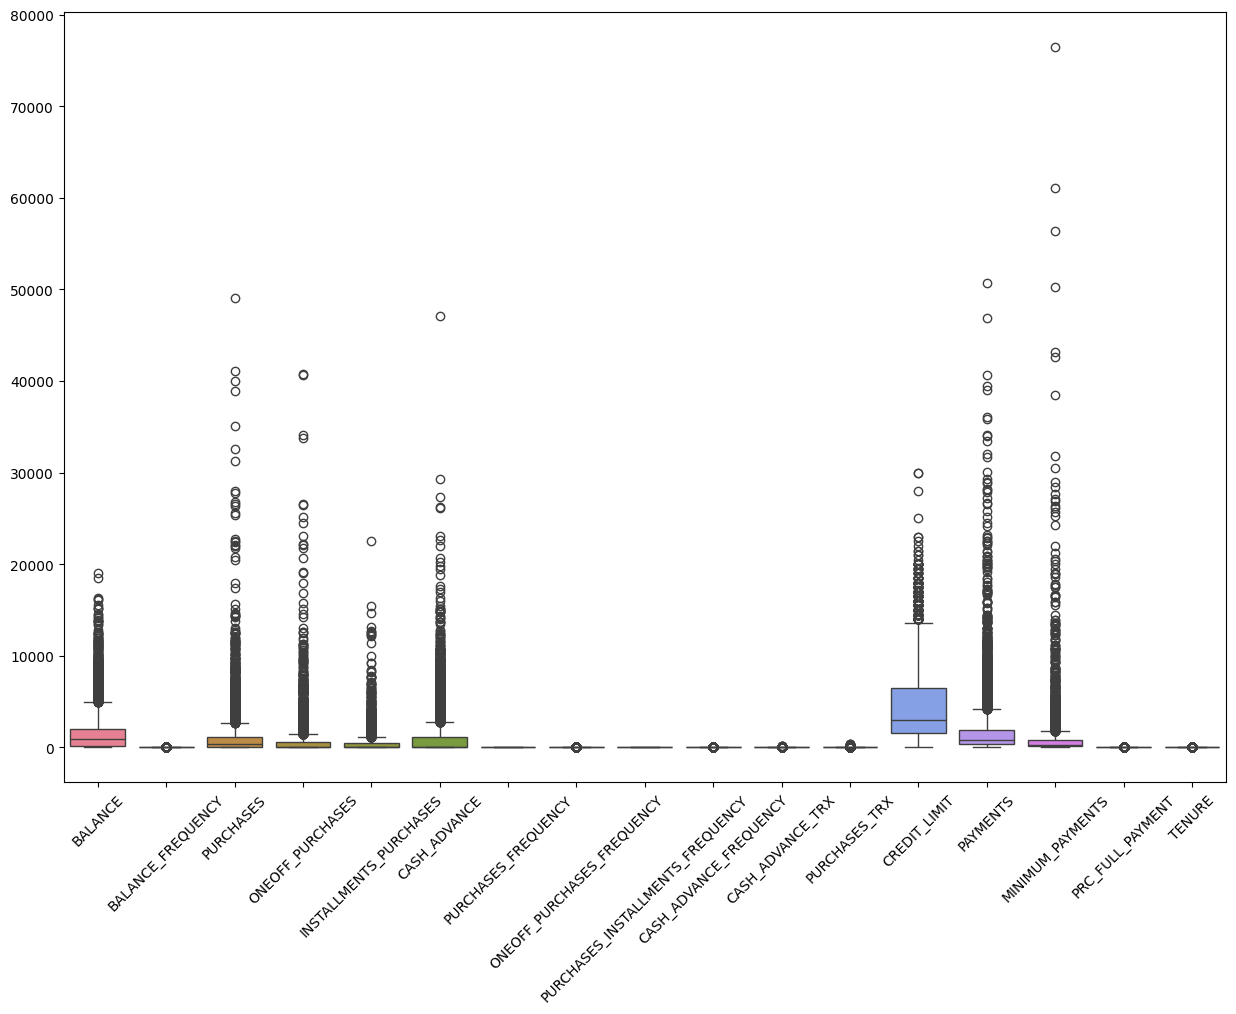

In [16]:
plt.figure(figsize=(15, 10))
plt.xticks(rotation=45)
sns.boxplot(data=numerical_cols)

Plenty of outliers, plenty of right skewed features as seen in the table of Descriptive Statistics and Bar plots. 

In [17]:
df = df.drop(['CUST_ID'], axis=1)

In [18]:
864.206542/ 312.343947

2.766842611488162

---
### **1.1. Imputation Techniques**

The mean and even median cannot be used for imputing for the missing values of Minimum Payments (313). Using the mean would be problematic because Minimum Payments is heavily right-skewed, with the mean being nearly three times that of the median (864.21 to 312.34). While the median would be more robust to outlers, the imputed value is only based on the Minimum Payments column, it does not take into consideration what a typical value would be given the values of the other columns. Even if a rule or constraint would be added such that Minimum Payments will always be less than or Equal to the corresponding value of the Payments column for the same row, the distribution can still be distorted and thus the variance would also be distorted. Median imputation may save time and be less computationally complex, especially given the few number of rows relative to the size of the data (The missing rows only account for about 3.5% of the data), its still worth using more robust methods.

Hence, for this demonstration two methods will be used: K-Nearest Neighbors (KNN) and Regression-Based Imputation. KNN takes into consideration the other variables and preserves the distribution and shape of Minimum Payments. Regression-Based imputation makes use of a simple linear model to predict the missing values. This is done by splitting the data into two groups: the first group contains all observations with no missing values, which is where the model is trained on. Then the observations with missing values are predicted by the trained model. For this, Minimum Payments becomes the target variable. The two approaches represent Non-Parametric and Parametric approaches respectively. 

For these, a few pre-processing techniques are needed. 

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, median_absolute_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split

In [20]:
#drop the rows with missing values for "CREDIT_LIMIT"
df = df.dropna(subset=["CREDIT_LIMIT"])

In [21]:
target_col = "MINIMUM_PAYMENTS"
feature_cols = list(df.columns[df.columns != target_col])

skewed_cols = feature_cols + [target_col]
data = df[feature_cols + [target_col]].copy()

for col in skewed_cols:
    data[col] = np.log1p(data[col].clip(lower=0))


In [22]:
print(len(df.columns), len(skewed_cols))

17 17


In [23]:
#Evaluation metric
def evaluate_both_spaces(y_true_log, y_pred_log, label=""):
    y_true_log = np.asarray(y_true_log)
    y_pred_log = np.asarray(y_pred_log)

    rmse_log = root_mean_squared_error(y_true_log, y_pred_log)
    mae_log = mean_absolute_error(y_true_log, y_pred_log)

    y_true_lin = np.expm1(y_true_log)
    y_pred_lin = np.expm1(y_pred_log)
    y_pred_lin = np.clip(y_pred_lin, a_min=0, a_max=None)  # no negative payments

    rmse_lin = root_mean_squared_error(y_true_lin, y_pred_lin)
    mae_lin = mean_absolute_error(y_true_lin, y_pred_lin)
    medae_lin = median_absolute_error(y_true_lin, y_pred_lin)

    print(f"{label}")
    print(f"Log space    : RMSE: {rmse_log:.4f} | MAE: {mae_log:.4f}")
    print(f"Linear space : RMSE: {rmse_lin:.2f} | MAE: {mae_lin:.2f} | MedAE: {medae_lin:.2f}")
    print()

    return {
        "label": label,
        "rmse_log": rmse_log, "mae_log": mae_log,
        "rmse_lin": rmse_lin, "mae_lin": mae_lin, "medae_lin": medae_lin
    }

In [24]:
#validation split

known_idx = data[data[target_col].notna()].index.values

train_idx, val_idx = train_test_split(
    known_idx, test_size=0.2, random_state=42
)

y_val_true = data.loc[val_idx, target_col].copy()

---
#### **1.1.1 KNN Imputation**

In [25]:
def knn_cv_rmse(data, target_col, k, known_idx, n_splits=5, random_state=42):
    """CV RMSE (log space) over the known rows, used only for k selection."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    errors = []

    for _, test_pos in kf.split(known_idx):
        test_rows = known_idx[test_pos]

        data_masked = data.copy()
        true_vals = data_masked.loc[test_rows, target_col].copy()
        data_masked.loc[test_rows, target_col] = np.nan

        scaler = StandardScaler()
        scaled = pd.DataFrame(
            scaler.fit_transform(data_masked),
            columns=data_masked.columns, index=data_masked.index
        )

        imputer = KNNImputer(n_neighbors=k)
        imputed_scaled = imputer.fit_transform(scaled)
        imputed = pd.DataFrame(
            scaler.inverse_transform(imputed_scaled),
            columns=data_masked.columns, index=data_masked.index
        )

        rmse = root_mean_squared_error(true_vals, imputed.loc[test_rows, target_col])
        errors.append(rmse)

    return np.mean(errors)

In [26]:
# Use only the training portion of known_idx for k selection (val stays untouched)
train_only_idx = train_idx.copy()

k_candidates = [3, 5, 7, 9, 11, 13, 15, 17]
cv_results = {}
for k in k_candidates:
    score = knn_cv_rmse(data, target_col, k, train_only_idx)
    cv_results[k] = score
    print(f"k={k:>2} | CV RMSE (log-space) = {score:.4f}")

best_k = min(cv_results, key=cv_results.get)
print(f"\nBest k selected: {best_k}\n")

k= 3 | CV RMSE (log-space) = 0.6819
k= 5 | CV RMSE (log-space) = 0.6639
k= 7 | CV RMSE (log-space) = 0.6633
k= 9 | CV RMSE (log-space) = 0.6628
k=11 | CV RMSE (log-space) = 0.6640
k=13 | CV RMSE (log-space) = 0.6669
k=15 | CV RMSE (log-space) = 0.6678
k=17 | CV RMSE (log-space) = 0.6694

Best k selected: 9



Generating dynamic grid plot...


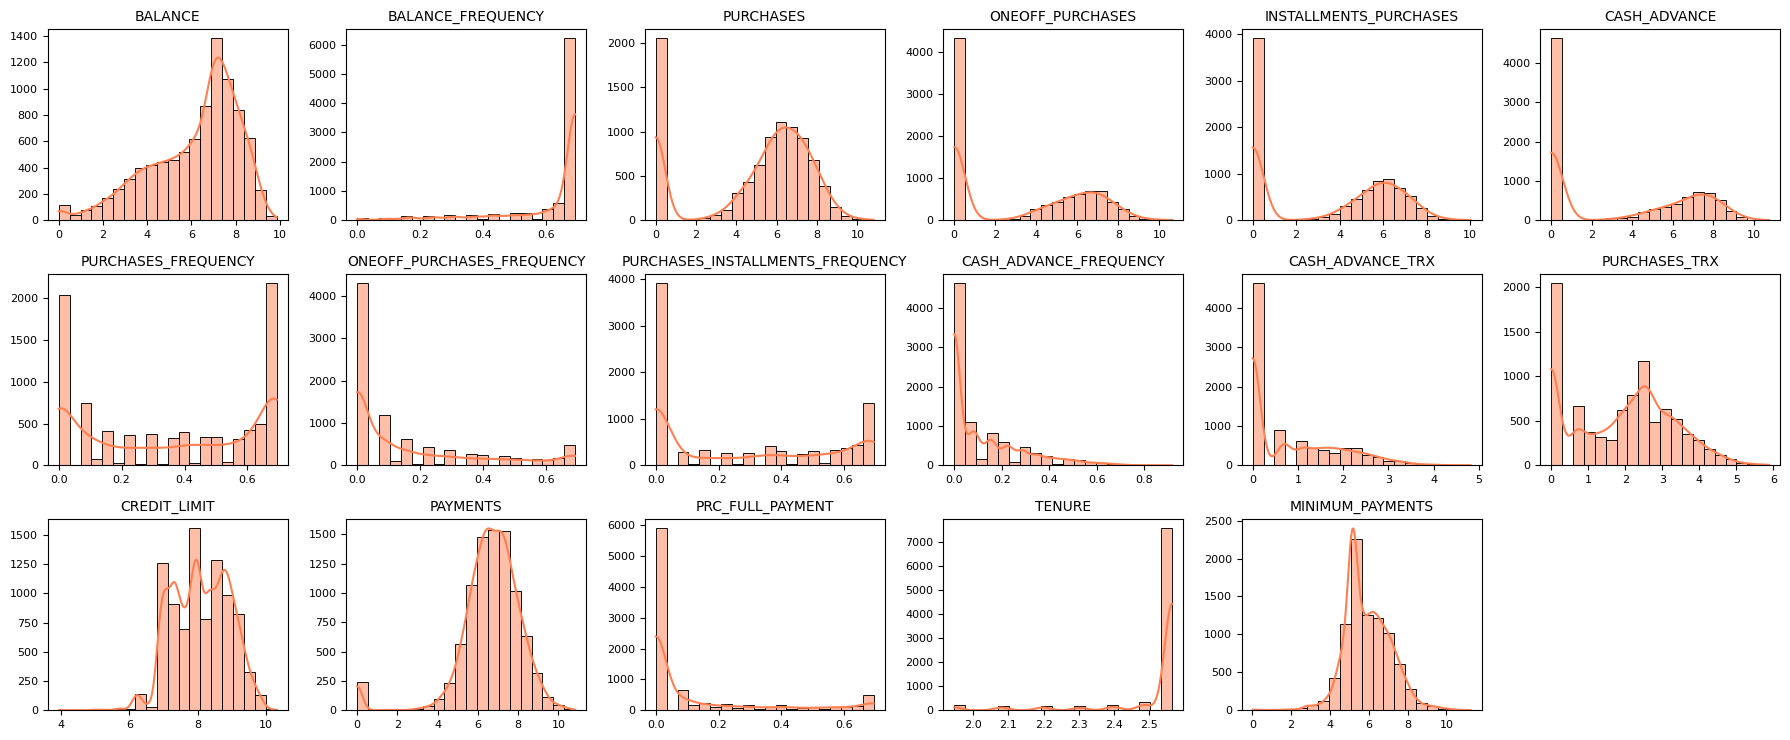

Note: This is before standardization


In [27]:
plot_all_features_grid(data, 6)
print("Note: This is before standardization")

In [28]:
#use the shared validation split
data_masked_knn = data.copy()
data_masked_knn.loc[val_idx, target_col] = np.nan  # mask val rows only

scaler_knn = StandardScaler()
scaled_knn = pd.DataFrame(
    scaler_knn.fit_transform(data_masked_knn),
    columns=data_masked_knn.columns, index=data_masked_knn.index
)

knn_imputer_final = KNNImputer(n_neighbors=best_k)
imputed_scaled_knn = knn_imputer_final.fit_transform(scaled_knn)
imputed_knn = pd.DataFrame(
    scaler_knn.inverse_transform(imputed_scaled_knn),
    columns=data_masked_knn.columns, index=data_masked_knn.index
)

y_val_pred_knn = imputed_knn.loc[val_idx, target_col]
results_knn = evaluate_both_spaces(y_val_true, y_val_pred_knn, label="KNN Imputation")

KNN Imputation
Log space    : RMSE: 0.6554 | MAE: 0.4403
Linear space : RMSE: 1948.72 | MAE: 486.10 | MedAE: 101.92



---
#### **1.1.2 Regression Imputation**

Using the same variables "target_col" as the target variable and "right_skewed_columns" as the feature set, a linear regression model is trained to predict the missing values. 

In [29]:
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, target_col]
X_val = data.loc[val_idx, feature_cols]

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_val_scaled = scaler_reg.transform(X_val)

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

y_val_pred_reg = reg_model.predict(X_val_scaled)
results_reg = evaluate_both_spaces(y_val_true, y_val_pred_reg, label="Linear Regression Imputation")

2026/08/18 13:02:13 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a070295944054ff396b3ea0f1a9b726a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 13:02:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/08/18 13:02:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression Imputation
Log space    : RMSE: 0.6524 | MAE: 0.4677
Linear space : RMSE: 1930.89 | MAE: 475.58 | MedAE: 114.68



---
#### **1.1.3 Comparison and Final Imputation**

To make sense of the values for Mean Absolute Error, it is compared to the median of the target column. 

In [30]:
comparison = pd.DataFrame([results_knn, results_reg]).set_index("label")
print(comparison)

print(f"\nMedian of Minimum Payments:{df['MINIMUM_PAYMENTS'].median()}")

best_method = comparison["mae_lin"].idxmin()
print(f"\nBest method based on linear-space MAE: {best_method}")

                              rmse_log   mae_log     rmse_lin     mae_lin  \
label                                                                       
KNN Imputation                0.655392  0.440327  1948.717217  486.102248   
Linear Regression Imputation  0.652369  0.467731  1930.892271  475.575779   

                               medae_lin  
label                                     
KNN Imputation                101.920866  
Linear Regression Imputation  114.677267  

Median of Minimum Payments:312.4522915

Best method based on linear-space MAE: Linear Regression Imputation


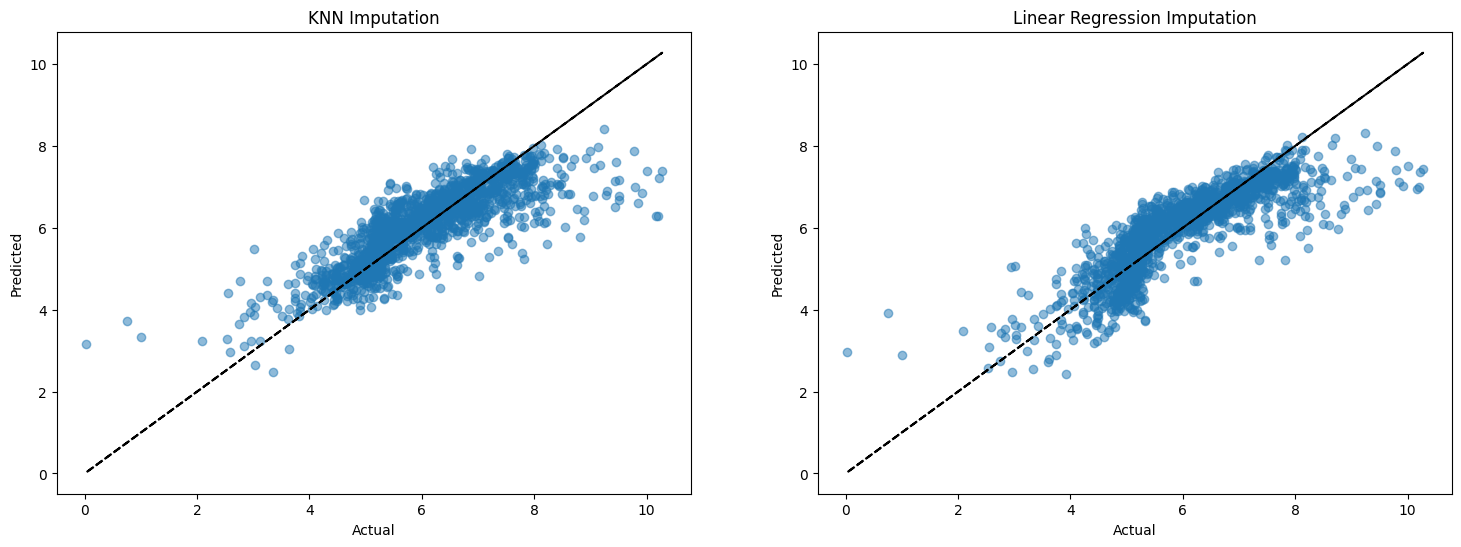

In [31]:
#plot predicted vs actual

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, (y_true, y_pred, label) in enumerate([
    (y_val_true, y_val_pred_knn, "KNN Imputation"),
    (y_val_true, y_val_pred_reg, "Linear Regression Imputation")
]):
    axes[i].plot(y_true, y_pred, "o", alpha=0.5)
    axes[i].plot(y_true, y_true, "k--")
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")
    axes[i].set_title(label)

Given these results, using KNN or Regression imputation is considerably worse than using median imputation instead. The outliers have a significant pull on mean or simply because of weak feature relationships. 

In [32]:
#Median imputation on the missing data of df

df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8949 non-null   float64
 1   BALANCE_FREQUENCY                 8949 non-null   float64
 2   PURCHASES                         8949 non-null   float64
 3   ONEOFF_PURCHASES                  8949 non-null   float64
 4   INSTALLMENTS_PURCHASES            8949 non-null   float64
 5   CASH_ADVANCE                      8949 non-null   float64
 6   PURCHASES_FREQUENCY               8949 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8949 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8949 non-null   float64
 10  CASH_ADVANCE_TRX                  8949 non-null   int64  
 11  PURCHASES_TRX                     8949 non-null   int64  
 12  CREDIT_LIMI

---
### **2. Dimensionality Reduction and Clustering**


Dimensionality reduction is typically a pre-cursor to Clustering, hence it is used here to check if it is needed. Though, some of the results from the Exploratory Data Analysis part may have already shown that it isn't necessary. 

In [34]:
#import PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [88]:
#log transform
df1 = df.copy()
for col in df1.columns:
    df1[col] = np.log1p(df1[col].clip(lower=0))

In [89]:
scaled_df = StandardScaler().fit_transform(df1)

2026/08/18 13:52:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a6e6b6ebe1d14ad385e7b1e8f7d364d2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/08/18 13:52:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 13:52:29 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/18 13:52:33 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


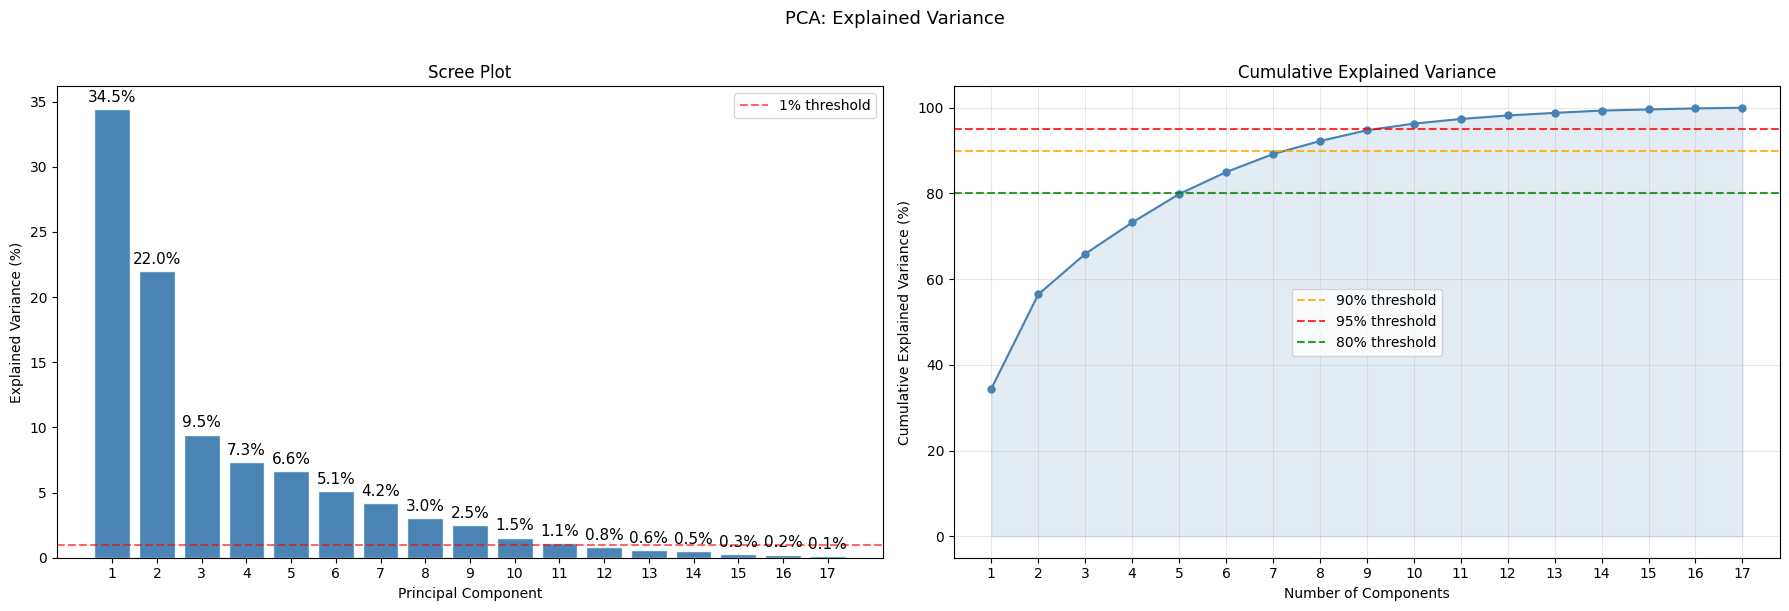

EXPLAINED VARIANCE BY COMPONENT

  PC01: 34.46%  |  Cumulative:  34.46%
  PC02: 22.00%  |  Cumulative:  56.45%
  PC03:  9.46%  |  Cumulative:  65.91%
  PC04:  7.32%  |  Cumulative:  73.23%
  PC05:  6.64%  |  Cumulative:  79.87%
  PC06:  5.12%  |  Cumulative:  84.99%
  PC07:  4.20%  |  Cumulative:  89.19%
  PC08:  3.04%  |  Cumulative:  92.23%
  PC09:  2.52%  |  Cumulative:  94.75%
  PC10:  1.54%  |  Cumulative:  96.29%

  Components needed to explain 80% of variance: 6
  Components needed to explain 90% of variance: 8
  Components needed to explain 95% of variance: 10
  Feature count: 17
  Compression ratio (90% threshold): 8/30 = 26.7%
  For Reference, the number of features (excluding CUST_ID) is 17


In [61]:
pca = PCA(random_state=42)
pca.fit(scaled_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scree plot
components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
axes[0].bar(
    components, pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)

bars = axes[0].bar(
    components, pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)

axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.6, label='1% threshold')
axes[0].legend()

axes[0].set_xticks(components)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, color='black', fontsize=11)

# Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(components, cumvar, 'o-', color='steelblue', markersize=5)
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.8, label='90% threshold')
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.8, label='95% threshold')
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.8, label='80% threshold')
axes[1].fill_between(components, cumvar, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[1].set_xticks(components)

plt.suptitle('PCA: Explained Variance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Report
print("EXPLAINED VARIANCE BY COMPONENT\n")
cumulative = 0
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    cumulative += var
    print(f"  PC{i+1:02d}: {var*100:5.2f}%  |  Cumulative: {cumulative*100:6.2f}%")

n_80 = np.argmax(cumvar >= 80) + 1
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
print()
print(f"  Components needed to explain 80% of variance: {n_80}")
print(f"  Components needed to explain 90% of variance: {n_90}")
print(f"  Components needed to explain 95% of variance: {n_95}")
print(f"  Feature count: {scaled_df.shape[1]}")
print(f"  Compression ratio (90% threshold): {n_90}/30 = {n_90/30:.1%}")
print(f"  For Reference, the number of features (excluding CUST_ID) is {scaled_df.shape[1]}")

2026/08/18 13:52:34 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ccb59237b19b4e94a1b56c3a5859f890', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 13:52:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 13:52:34 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/18 13:52:38 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model traini

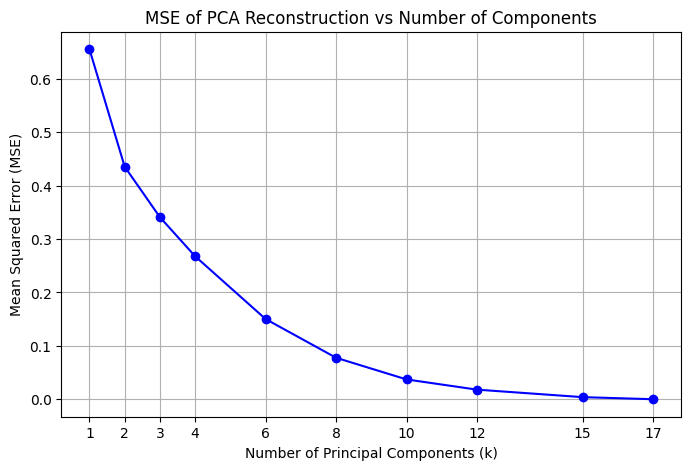

In [62]:
# PCA Reconstruction
k_values = [1, 2, 3, 4, 6, 8, 10, 12, 15, 17]
mse_list = []
mse_k2 = None

for k in k_values:
    pca = PCA(n_components=k, random_state=42)
    transformed = pca.fit_transform(scaled_df)
    reconstructed = pca.inverse_transform(transformed)
    
    mse_per_row = np.mean((scaled_df - reconstructed) ** 2, axis=1)
    mse = np.mean(mse_per_row)
    mse_list.append(mse)
    
    if k == 2:
        mse_k2 = mse_per_row

plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_list, marker='o', linestyle='-', color='b')
plt.title('MSE of PCA Reconstruction vs Number of Components')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(k_values)
plt.grid(True)

---
#### **PCA to K-means clustering**

In [99]:
pca = PCA(n_components=8, random_state=42)
transformed = pca.fit_transform(scaled_df)

df_pca = pd.DataFrame(transformed)

2026/08/18 15:30:13 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e0f0daacf4ba4514a665969231ded636', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 15:30:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 15:30:14 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/18 15:30:17 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model traini

In [100]:
df_pca

,0,1,2,3,4,5,6,7
0,-0.256067,-2.663171,-0.315952,1.065398,-0.402200,0.159848,-0.694772,0.218910
1,-3.492152,1.012543,-0.053186,0.209579,1.744869,0.483788,0.694067,0.084827
2,1.464428,1.287278,2.719587,0.918893,-0.776281,0.156725,0.462758,-0.732428
3,-1.276676,-1.086574,1.867277,0.446709,-1.637617,-2.204890,0.403199,-2.569507
4,-1.152992,-1.349447,0.916627,1.675700,-0.431077,1.208028,-0.331780,0.379165
...,...,...,...,...,...,...,...,...
8944,1.739485,-2.877110,-2.115558,-2.532135,-2.036120,2.358886,1.801047,0.372158
8945,1.261637,-2.186330,-2.238427,-1.384227,-3.126375,1.238413,2.017868,0.962449
8946,1.072218,-3.245545,-1.788795,-2.141120,-2.734507,1.407078,1.878068,0.265167
8947,-2.778855,-3.887530,-0.501795,-2.696130,-2.620402,2.128948,0.912859,0.017737


2026/08/18 15:30:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ea5cbbc72c8540ed9e5c66a3bbf51edb', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 15:30:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 15:30:27 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/18 15:30:27 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '255e871

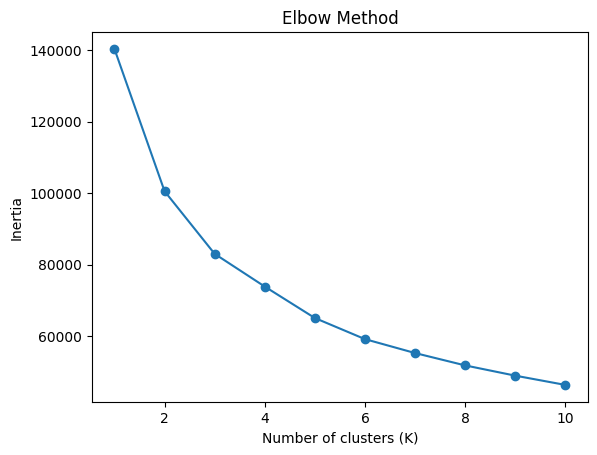

In [101]:
#kmeans usign the pca transformed data
K_range = range(1, 11)
inertia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
#plt.axvline(x=3, color='red', linestyle='--')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

2026/08/18 15:35:46 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '918cffb05dee469592ac1337160e2ba8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 15:35:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 15:35:51 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/18 15:35:53 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd6ce1d3

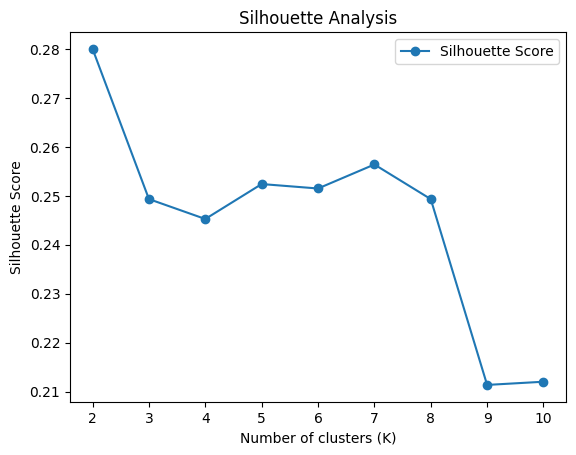

In [102]:
K_range = range(2, 11)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)
    sil_scores.append(silhouette_score(df_pca, labels))

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
#plt.axvline(x=3, color='red', linestyle='--') 
plt.legend(['Silhouette Score', 'Chosen K'])
plt.title('Silhouette Analysis')
plt.show()

---
#### **UMAP reducer to K-means**

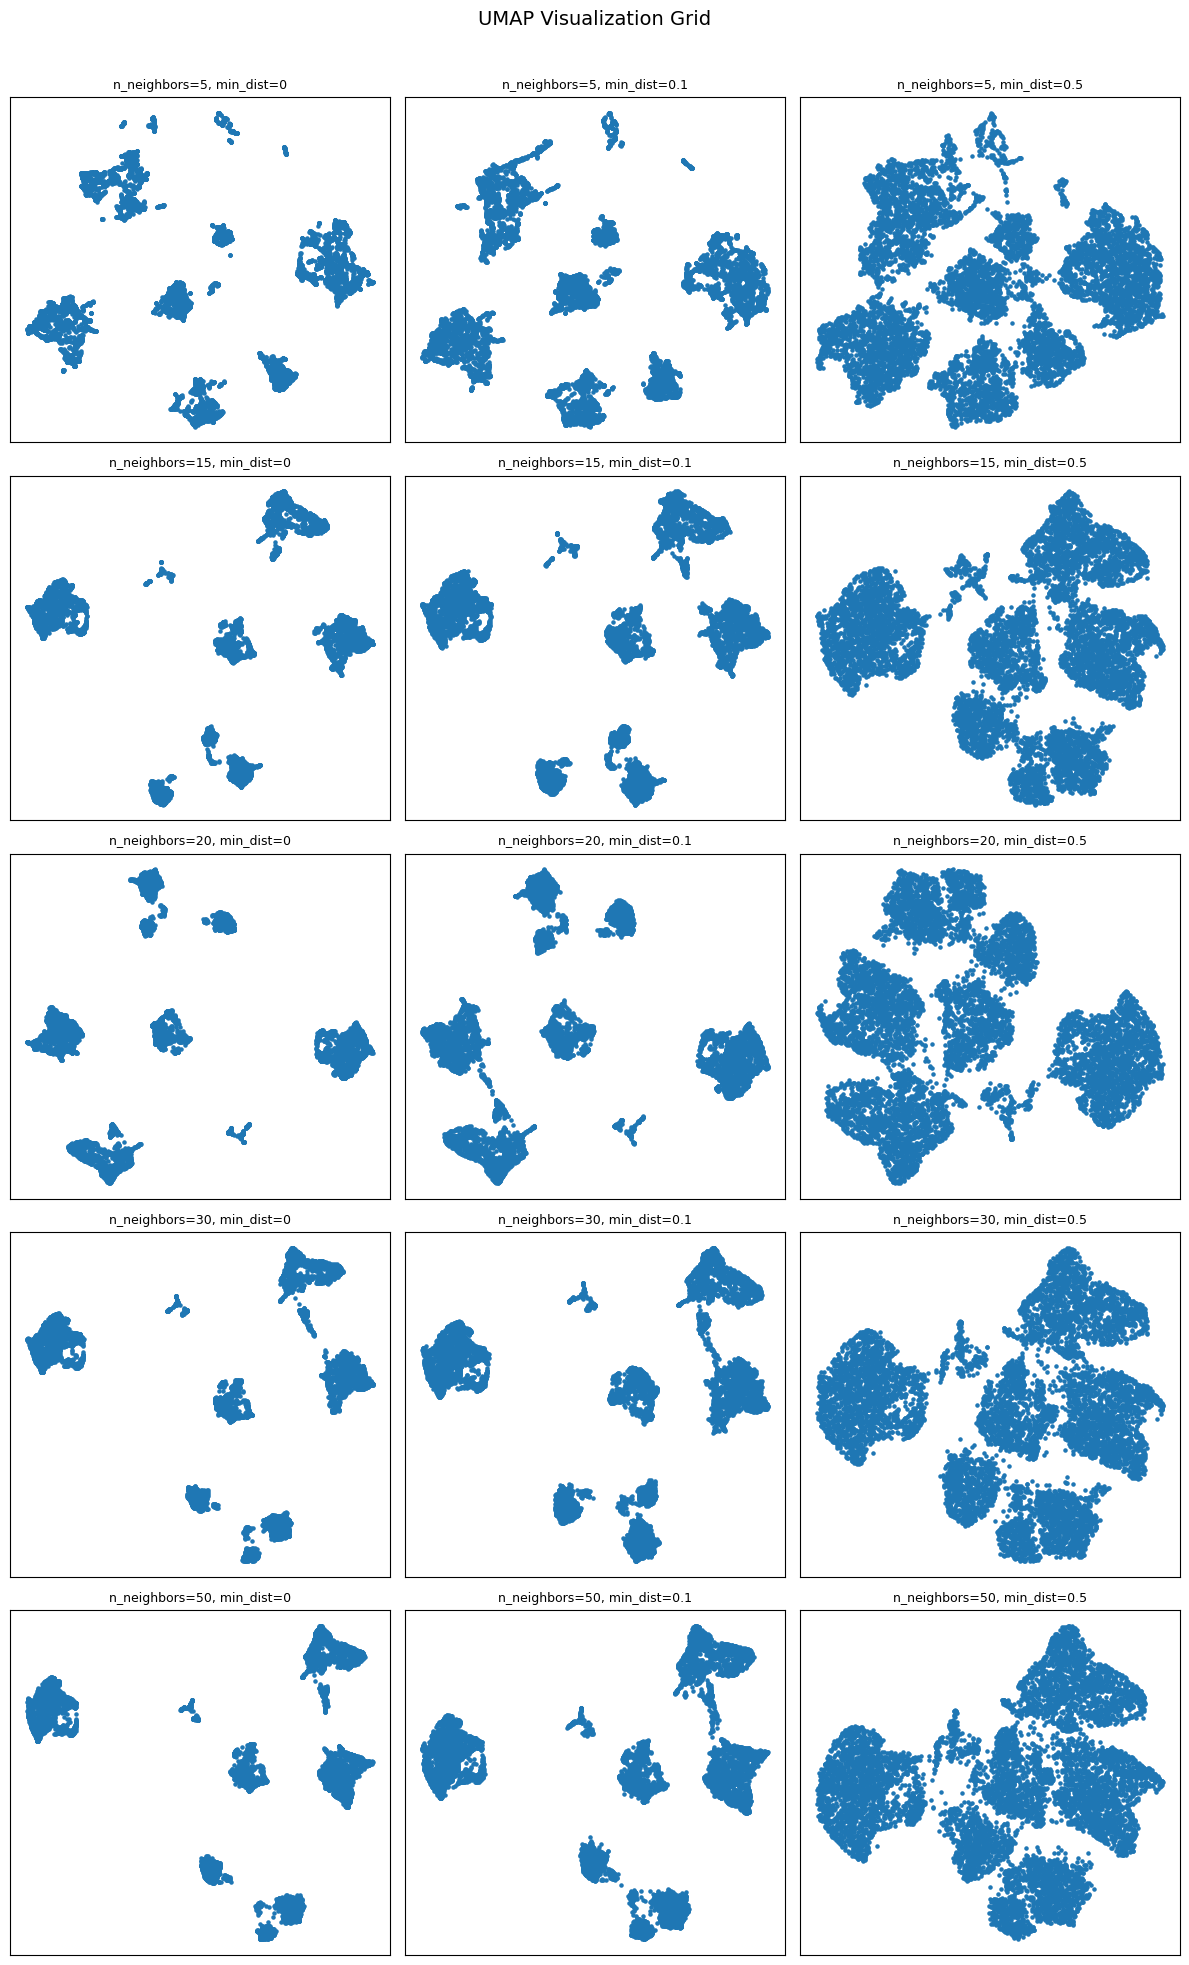

In [ ]:
n_neighbors_list = [5, 15, 20, 30, 50]
min_dist_list = [0, 0.1, 0.5]

fig, axes = plt.subplots(
    len(n_neighbors_list), len(min_dist_list),
    figsize=(4 * len(min_dist_list), 4 * len(n_neighbors_list))
)

for i, n in enumerate(n_neighbors_list):
    for j, md in enumerate(min_dist_list):
        reducer = umap.UMAP(
            n_neighbors=n, min_dist=md, n_components=2, random_state=42
        )
        embedding = reducer.fit_transform(scaled_df)

        ax = axes[i, j]
        ax.scatter(embedding[:, 0], embedding[:, 1], s=5)
        ax.set_title(f"n_neighbors={n}, min_dist={md}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("UMAP Visualization Grid", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [95]:
def umap_reduce(X, min_dist=0.1, n_neighbors=15, n_components=2, random_state=42):
    """
    Reduce dimensionality of data using UMAP.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Input data to reduce.
    min_dist : float, default=0.1
        Minimum distance between points in the low-dimensional embedding.
    n_neighbors : int, default=15
        Number of local neighbors used to build the manifold structure.
    n_components : int, default=2
        Dimension of the reduced space.
    random_state : int, default=42
        Seed for reproducibility.

    Returns
    -------
    X_embedded : ndarray of shape (n_samples, n_components)
        The reduced-dimensional representation.
    reducer : umap.UMAP
        The fitted UMAP object (for transforming new data later).
    """
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        random_state=random_state,
    )
    X_embedded = reducer.fit_transform(X)
    return X_embedded, reducer

def kmeans_cluster(X, n_clusters, random_state=42):
    """
    Perform k-means clustering on the (reduced) data.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Data to cluster (typically the UMAP-reduced representation).
    n_clusters : int
        Number of clusters to form.
    random_state : int, default=42
        Seed for reproducibility.

    Returns
    -------
    labels : ndarray of shape (n_samples,)
        The cluster labels assigned to each sample.
    kmeans : KMeans
        The fitted KMeans object.
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(X)
    return labels, kmeans

2026/08/18 16:06:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9eb5af33ee594a92af816d7a947dfd9f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 16:06:45 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/18 16:06:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 16:06:45 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/18 16:06:49 WARNI

Text(0, 0.5, 'Trustworthiness')

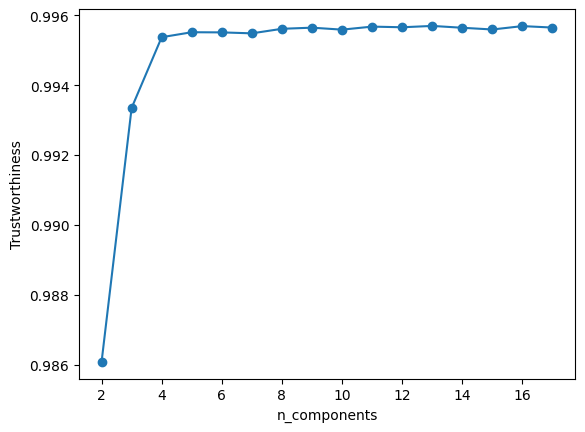

In [ ]:
from sklearn.manifold import trustworthiness
scores = {}
for n in [x for x in range(2, 18)]:
    reducer = umap.UMAP(n_components=n, random_state=42)
    embedding = reducer.fit_transform(scaled_df)
    scores[n] = trustworthiness(scaled_df, embedding, n_neighbors=15)

plt.xlabel('n_components')
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.ylabel('Trustworthiness')

2026/08/18 16:16:55 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5ae480ae644e41dcb44375254f798a56', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 16:16:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 16:16:59 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/18 16:16:59 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8e60e5e

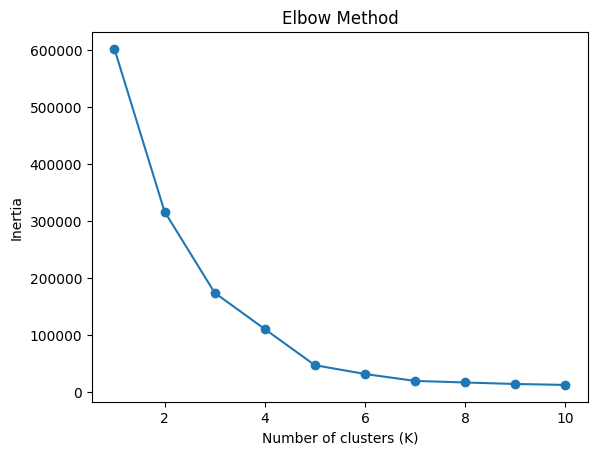

In [116]:
reduced_df = umap_reduce(scaled_df,  n_components=4)

K_range = range(1, 11)
inertia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(reduced_df[0])
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
#plt.axvline(x=3, color='red', linestyle='--')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

2026/08/18 16:17:49 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5167939919da46fab33041b61180cd2d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 16:17:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 16:17:52 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/18 16:17:54 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '6d432ad

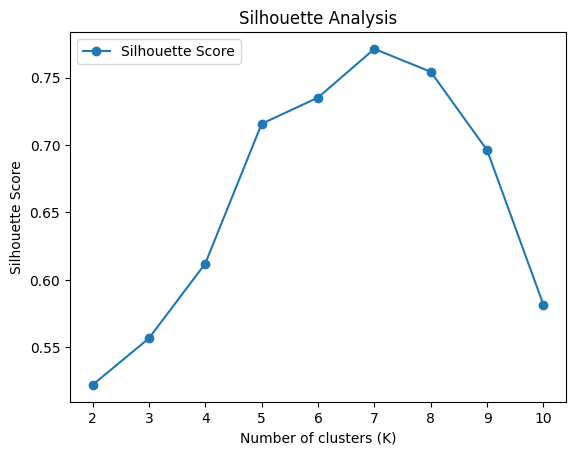

In [117]:
K_range = range(2, 11)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(reduced_df[0])
    sil_scores.append(silhouette_score(reduced_df[0], labels))

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
#plt.axvline(x=3, color='red', linestyle='--') 
plt.legend(['Silhouette Score', 'Chosen K'])
plt.title('Silhouette Analysis')
plt.show()

In [121]:
#cluster metrics for k=7
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(reduced_df[0])
sil_scores.append(silhouette_score(reduced_df[0], labels))

sil_score = silhouette_score(reduced_df[0], labels)
db_score = davies_bouldin_score(reduced_df[0], labels)
ch_score = calinski_harabasz_score(reduced_df[0], labels)

print(sil_score)
print(db_score)
print(ch_score)

2026/08/18 16:19:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '809fc180c8c0426e805c71f80e3387b2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 16:19:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 16:20:02 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


0.6121407747268677
0.6486319579942715
13233.8544921875


---
##### **Log Transform and Scale Data**

In [ ]:
df1 = df.copy()
for col in df1.columns:
    df1[col] = np.log1p(df1[col].clip(lower=0))

scaled_df = StandardScaler().fit_transform(df1)    

In [104]:
columns = ['UMAP to K-Means', 'UMAP to DBSCAN', 'UMAP to HDBSCAN',
           'PCA to K-Means', 'PCA to DBSCAN', 'PCA to HDBSCAN']
index = ['Calinski-Harabasz', 'Davies-Bouldin', 'Silhouette Score']

clustering_df = pd.DataFrame(np.nan, index=index, columns=columns)

In [107]:
#Note for density based clustering use:
#mask = labels != -1
#sil_score = silhouette_score(scaled_df[mask], labels[mask])

##### **PCA to K-means**

In [112]:
pca = PCA(n_components=8, random_state=42)
transformed = pca.fit_transform(scaled_df)
df_pca = pd.DataFrame(transformed)

labels, kmeans = kmeans_cluster(df_pca, 3)
sil_scores.append(silhouette_score(df_pca, labels))

sil_score = silhouette_score(df_pca, labels)
db_score = davies_bouldin_score(df_pca, labels)
ch_score = calinski_harabasz_score(df_pca, labels)

clustering_df.loc['Silhouette Score', 'PCA to K-Means'] = sil_score
clustering_df.loc['Davies-Bouldin', 'PCA to K-Means'] = db_score
clustering_df.loc['Calinski-Harabasz', 'PCA to K-Means'] = ch_score

print(sil_score)
print(db_score)
print(ch_score)

2026/08/18 16:01:55 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'cd59f0a7d89740d68688a6a3e90b15a6', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/18 16:01:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/18 16:01:55 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/18 16:01:59 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model traini

0.2493346654982075
1.5554166100916333
3085.335888211598


##### **UMAP to K-means**

---
### **3. Cluster Profiles**


---
### **4. Multiple Model Training for Classification**


---
### **5. Performance Metrics**


---
### **6. Conclusion**
